# DrugEx ROCS Quick Start: Shape-Based RL

RL training for CCR2 ligand design using RDKit ROCS shape similarity scoring.

**Prerequisites:** Run fine-tuning first (`python prepare_models.py`)

**What This Does:**
- Trains RL model to generate CCR2 ligands optimized for shape similarity (ROCS) and synthetic accessibility
- Uses predefined settings from `config.py`
- Saves trained model for molecule generation

## ROCS Threshold Validation

Before RL training, we validate the ROCS threshold used to reward shape-similar molecules. 

**Why:** The threshold determines which molecules are considered "desired" during RL. Too high → miss actives. Too low → reward decoys.

**Method:** ROC analysis compares 75 CCR2 actives vs 500 decoys using the same conformer settings as RL training. We find the optimal threshold that maximizes separation (Youden's Index).

Results validate whether `config.py`'s `ROCS_THRESHOLD = 1.2` is appropriate or should be adjusted.

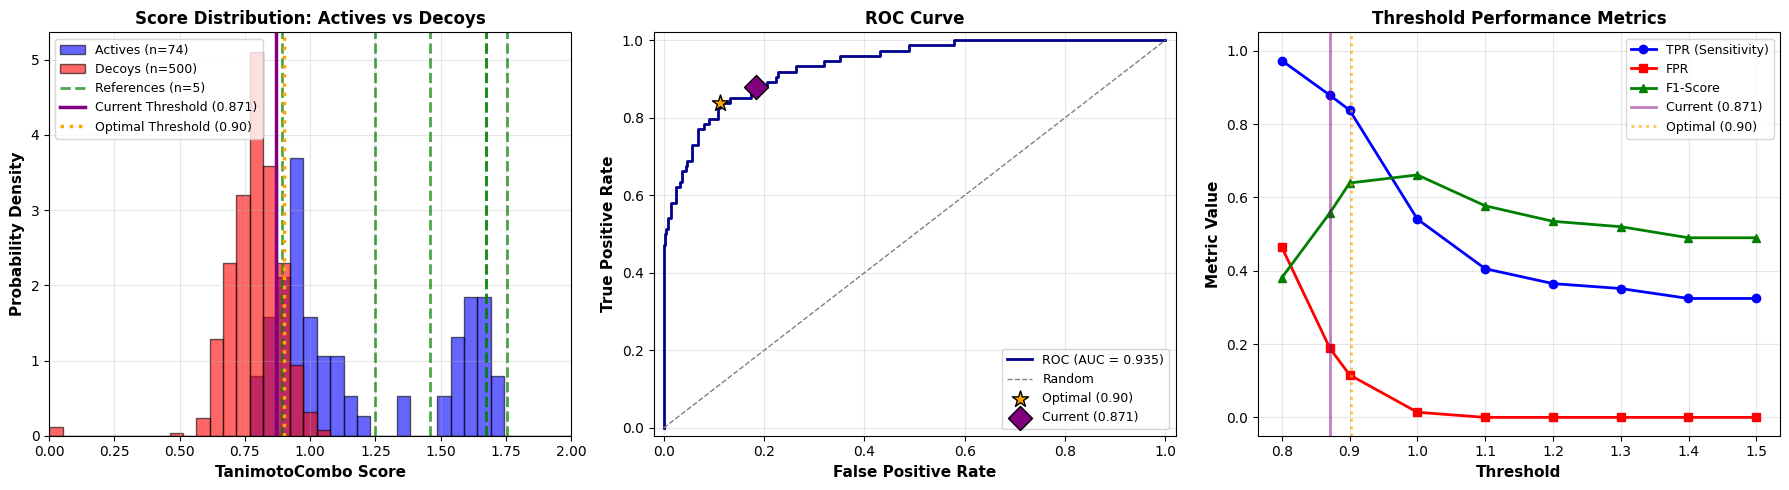

Current config threshold: 0.871
Optimal threshold (Youden's Index): 0.902


In [1]:
# Run threshold validation (uses config.py defaults automatically)
from threshold_analysis import run_threshold_analysis
from config import ROCS_THRESHOLD

results = run_threshold_analysis(
    actives_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/actives_ccr2_N75.csv',
    decoys_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/decoys_ccr2_N500.csv',
    verbose=False, 
    show_plots=True

)

# Display threshold recommendation
optimal_threshold = results['optimal_threshold']
print(f"Current config threshold: {ROCS_THRESHOLD}")
print(f"Optimal threshold (Youden's Index): {optimal_threshold:.3f}")


In [26]:
# Imports
import time
import pandas as pd
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
from rdkit import Chem
from rdkit.Chem import Draw

# Demo RL parameters - faster for tutorial
RL_EPOCHS = 50      # Training epochs
RL_EPSILON = 0.2    # Exploration rate
RL_N_SAMPLES = 500  # Molecules per epoch (config.py uses 1000)


### Example: Manual Initialization

Below is how you would manually create these components (equivalent to what's in `config.py`):

In [3]:
# Setup with demo settings (faster for tutorial)
from pathlib import Path
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.environment import DrugExEnvironment
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.scorers.properties import Property
from drugex.training.scorers.conformer_generators import RDKitConformerGenerator
from drugex.training.scorers.rocs_rdkit import RDKitROCSScorer
from config import (
    FINETUNE_CHECKPOINT, FINETUNE_VOCAB, MODELS_PR_PATH, 
    OUTPUT_DIR, ROCS_THRESHOLD, SA_THRESHOLD
)


# Create ROCS scorer
CCR2_SDF = Path('rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf')
rocs_scorer = RDKitROCSScorer(
    conformer_generator=RDKitConformerGenerator(
        max_conformers=30,
        max_isomers=2,
        max_heavy_atoms=35,
        max_rotatable_bonds=10,
        num_threads=0,
        show_progress=False,
    ),
    references=str(CCR2_SDF),
    score_type='TanimotoCombo',
    use_colors=True,
    show_progress=False,
    n_jobs=-1,
)

# SA scorer
sa_scorer = Property('SA')
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))

# Create environment with both scorers
env = DrugExEnvironment(
    scorers=[rocs_scorer, sa_scorer],
    thresholds=[ROCS_THRESHOLD, SA_THRESHOLD],
    reward_scheme=ParetoCrowdingDistance()
)

# Load vocabulary and models
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
voc = VocSmiles.fromFile(str(FINETUNE_VOCAB), encode_frags=False)

agent = SequenceRNN(voc, is_lstm=True)
agent.loadStatesFromFile(str(Path(MODELS_PR_PATH) / 'Papyrus05.5_smiles_rnn_PT.pkg'))

mutate = SequenceRNN(voc, is_lstm=True)
mutate.loadStatesFromFile(str(FINETUNE_CHECKPOINT))

output_dir = OUTPUT_DIR

print(f"Setup complete! Device: {agent.device}")
print(f"Demo settings: {10} conformers, {1} isomers")

# Alternative backends (for showcase - not used in this tutorial)
# Uncomment to try different backends:

# CDPKit backend (open source)
# from drugex.training.scorers.conformer_generators import CDPKitConformerGenerator
# from drugex.training.scorers.rocs_cdpkit import CDPKitROCSScorer
# cdpkit_gen = CDPKitConformerGenerator(
#     max_conformers=30,
#     max_isomers=2,
#     show_progress=False
# )
# cdpkit_scorer = CDPKitROCSScorer(
#     conformer_generator=cdpkit_gen,
#     references=str(CCR2_SDF),
#     n_jobs=-1
# )

# OpenEye backend (commercial)
# from drugex.training.scorers.conformer_generators import OmegaConformerGenerator
# from drugex.training.scorers.rocs_openeye import OpenEyeROCSScorer
# omega_gen = OmegaConformerGenerator(
#     max_conformers=30,
#     max_centers=2
# )
# openeye_scorer = OpenEyeROCSScorer(
#     conformer_generator=omega_gen,
#     references={"CCR2": str(CCR2_SDF)},
#     score_type="TanimotoCombo",
# )

Setup complete! Device: cuda:0
Demo settings: 10 conformers, 1 isomers


First we will have a look on our reference molecules: 

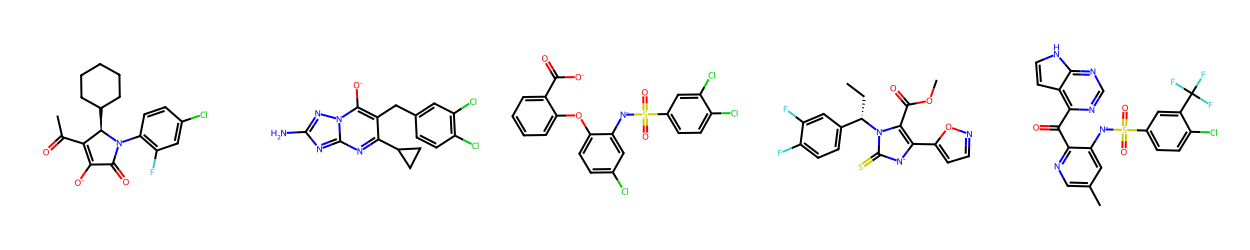

In [40]:
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw

CCR2_SDF = Path("rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf")

mols_raw = [m for m in Chem.SDMolSupplier(str(CCR2_SDF), removeHs=False) if m]
smiles_can = [Chem.MolToSmiles(m, canonical=True, isomericSmiles=True) for m in mols_raw]
mols_2d = [Chem.MolFromSmiles(s) for s in smiles_can]

Draw.MolsToGridImage(mols_2d, molsPerRow=5, subImgSize=(250, 250))


We have to first run the transfer learning to finetune the model

In [4]:
!python prepare_models.py

Fine-tuned model already exists: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/demo_out/models/CCR2_finetuned.pkg
Use --force to retrain


**Note:** Reference ligands support `.sdf` or `.sq` (OpenEye Shape Query) formats. See [README](README.md#reference-ligand-input-formats) for detailed format documentation.

In [5]:
# Create RL explorer
explorer = SequenceExplorer(
    agent=agent,
    env=env,
    mutate=mutate,
    epsilon=RL_EPSILON,
    n_samples=RL_N_SAMPLES,
)

print(f"RL Config: {RL_EPOCHS} epochs, epsilon={RL_EPSILON}, samples={RL_N_SAMPLES}")

RL Config: 50 epochs, epsilon=0.2, samples=500


In [6]:
# Train RL model
output_base = output_dir / 'CCR2_rdkit_reinforced'
monitor = FileMonitor(str(output_base), save_smiles=True, reset_directory=True)


Removing CCR2_rdkit_reinforced_fit.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced_fit.log from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced_smiles.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced.pkg from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl


In [7]:

start = time.time()
explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
monitor.close()

print(f"\nCompleted in {(time.time()-start)/60:.1f} minutes")
print(f"Model saved: {output_base}.pkg")

Fitting SMILES RNN explorer:   0%|          | 0/50 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]


Completed in 59.0 minutes
Model saved: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl/CCR2_rdkit_reinforced.pkg


In [8]:
df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')
df.head(5)


,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.98,0.98,0.28,0.785,0.742,0.094,1
1,2,0.98,0.98,0.24,0.862,0.847,0.364,1
2,3,0.96,0.96,0.26,0.868,0.855,0.155,1
3,4,0.94,0.94,0.32,0.866,0.860,0.148,4
4,5,0.92,0.92,0.30,0.846,0.820,0.097,4


In [9]:
df.tail(5)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
45,46,0.92,0.90,0.46,0.916,0.911,0.055,40
46,47,0.94,0.92,0.38,0.905,0.899,0.059,40
47,48,0.94,0.92,0.44,0.923,0.920,0.065,40
48,49,0.98,0.96,0.52,0.921,0.908,0.059,40
49,50,0.94,0.94,0.52,0.920,0.915,0.056,40


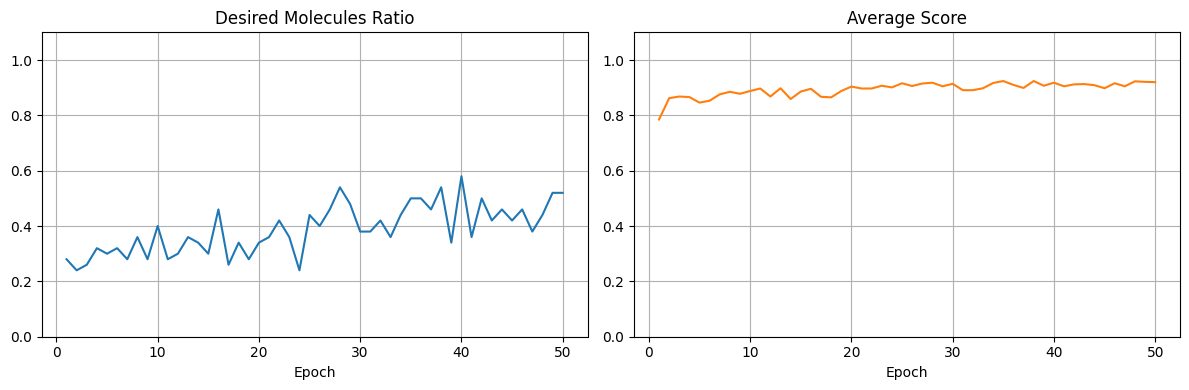

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')

df.plot(x='Epoch', y=['desired_ratio', 'avg_amean'], subplots=True, layout=(1,2),
        figsize=(12,4), ylim=(0,1.1), grid=True, legend=False, title=['Desired Molecules Ratio','Average Score'])

plt.tight_layout()
plt.show()


### Training summary
- **Desired Molecules Ratio (left)**: Rises from ~0.25 to ~0.6 over 50 epochs with oscillations, indicating more molecules meet the criteria as training progresses, this would be more visible using larger amount of samples each epoch and also higher number of conformers, for the time sake and to show we can see the trend.
- **Average Score (right)**: Starts high (~0.8) and gradually improves to ~0.95–0.97, staying stable with minor fluctuations—overall quality improves while the desired ratio increases.

## Generate New Molecules

Now that training is complete, we can generate novel molecules from the trained model and analyze their properties:

In [48]:
# Generate molecules from the trained model
df_gen = agent.generate(num_samples=1000, evaluator=env)

# Get scorer keys
scorer_keys = env.getScorerKeys()

Generating molecules:   0%|          | 0/1000 [00:00<?, ?it/s]

In [50]:
df_gen[["Valid", "Desired"]].value_counts()


Valid  Desired
1.0    0.0        516
       1.0        484
Name: count, dtype: int64

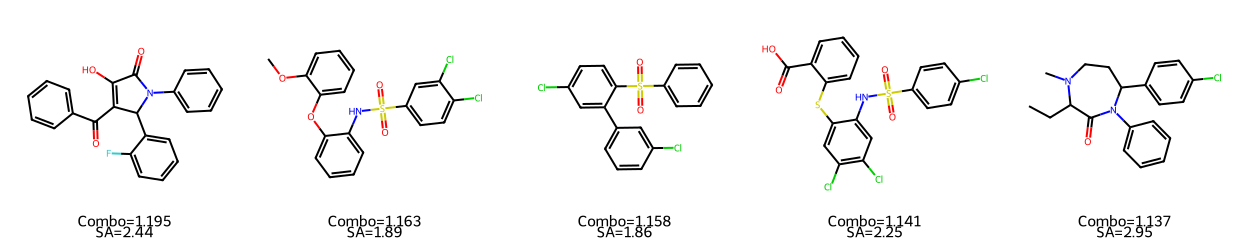

In [51]:
from rdkit import Chem
from rdkit.Chem import Draw

tanimoto_col = "RDKit_Aggregate_5refs_TanimotoCombo"

top5 = (df_gen[df_gen["Desired"].eq(1)]
        .sort_values(tanimoto_col, ascending=False)
        .head(5)
        .loc[:, ["SMILES","Valid","Desired",tanimoto_col,"SA"]])

mols = [Chem.MolFromSmiles(s) for s in top5["SMILES"]]
legends = [f"Combo={c:.3f}\nSA={sa:.2f}" for c, sa in zip(top5[tanimoto_col], top5["SA"])]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(250,250), legends=legends)


Now we can look at the generated molecules and input reference molecules we used for shape matching

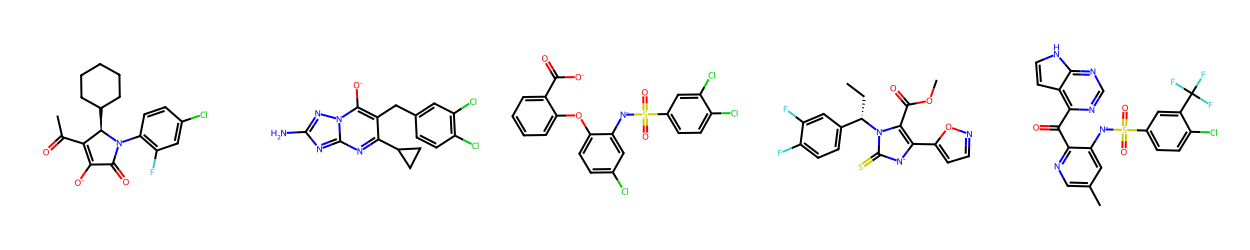

In [52]:
Draw.MolsToGridImage(mols_2d, molsPerRow=5, subImgSize=(250, 250))


## Next Steps

### Generate More Molecules (Optional)

You can generate additional molecules using the standalone script:

```bash
python generate_molecules.py --num-samples 1000
```

### Try Other ROCS Backends

- **CDPKit** (open source): `python run_cdpkit_rocs.py`
- **OpenEye** (commercial, GPU support): `python run_openeye_rocs.py`

### Customize Training

Edit `config.py` to experiment with:
- RL parameters (epochs, epsilon, samples)
- Conformer settings (max_conformers, max_isomers)
- Reference ligands (CCR2_SDF path)
- ROCS and SA thresholds